# MAB with beta-binomial & Beta-Bernoulli model

## Multi-Armed-Bandit with beta-binomial model

In [1]:
# using Pkg #UNCOMMENT IF PACKAGES NOT INSTALLED -> ALSO ADD [add IJulia] IF YOU WANT TO USE JUPYTERS BOOK
# Pkg.add("Gen") 
# Pkg.add("Plots")
# Pkg.add("Random")
# Pkg.add("Distributions")
using Gen, Plots, Random, Distributions, LinearAlgebra
# Random seed for reproducibility
Random.seed!(0)

# Model Definition for MAB
@gen function multi_armed_bandit_model(
    success_prior::Vector{Float64},
    fail_prior::Vector{Float64},
    n_pulls_per_arm::Vector{Int}
)
    n_arms = length(success_prior)
    
    # Calculate theta for arm i
    theta = [({(:theta, i)} ~ beta(success_prior[i], fail_prior[i])) for i in 1:n_arms]
    
    # Observation for arm i and theta i
    for i in 1:n_arms
        ({(:obs, i)} ~ binom(n_pulls_per_arm[i], theta[i]))
    end
    
    return theta
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Vector{Float64}, Vector{Float64}, Vector{Int64}], false, Union{Nothing, Some{Any}}[nothing, nothing, nothing], Main.var"##multi_armed_bandit_model#230", Bool[0, 0, 0], false)

### Inference Techniques from Gen (built-in)

In [2]:
# IMPORTANCE SAMPLING
function is_inference(model, args, observations, num_samples)
    (traces, log_weights, _) = Gen.importance_sampling(
        model,
        args,
        observations::Gen.ChoiceMap,
        num_samples
    )
    weights = exp.(log_weights)
    return traces, weights
end

# metropolis_hastings
function mh_inference(
    prior_success,
    prior_fail,
    n_pulls_per_arm,
    observations::Gen.ChoiceMap,
    num_iters;
    burn_in::Int=1000  # Discard first 1000 samples
)
    # Generate initial trace
    (trace, _) = Gen.generate(
        multi_armed_bandit_model,
        (prior_success, prior_fail, n_pulls_per_arm),
        observations
    )
    
    n_arms = length(prior_success)
    traces = Vector{Gen.Trace}()
    
    # Run MH updates and collect traces after burn-in
    for iter in 1:(num_iters + burn_in)
        # Update all theta parameters in sequence
        for arm in 1:n_arms
            selection = Gen.select((:theta, arm))
            (trace, _) = Gen.metropolis_hastings(trace, selection) # Assign new trace to old or accepted trace
        end
        
        # Store trace after burn-in period
        if iter > burn_in
            push!(traces, trace)
        end
    end
    
    return traces  # Return ALL post-burn-in traces
end

mh_inference (generic function with 1 method)

### Custom Inference Technique


In [3]:
# Sample from posterior that we can calculate using conjugate beta binomial
function beta_binomial_conjugate_inference(
    prior_success,
    prior_fail,
    n_pulls_per_arm,
    observations::Gen.ChoiceMap,
    num_samples
)
    n_arms = length(prior_success)
    successes = [observations[(:obs, i)] for i in 1:n_arms]
    
    # Calculate posterior parameters
    post_alpha = prior_success .+ successes
    post_beta = prior_fail .+ n_pulls_per_arm .- successes
    
    # Generate samples as proper Gen traces
    traces = Vector{Gen.Trace}()
    model_args = (prior_success, prior_fail, n_pulls_per_arm)
    
    for _ in 1:num_samples
        # Create choices with sampled thetas and fixed observations
        choices = Gen.choicemap()
        for i in 1:n_arms
            choices[(:theta, i)] = rand(Beta(post_alpha[i], post_beta[i]))
        end
        
        # Merge with observations
        merged_choices = Gen.merge(choices, observations)
        
        # Generate valid Gen trace
        trace, _ = Gen.generate(
            multi_armed_bandit_model,
            model_args,
            merged_choices
        )
        push!(traces, trace)
    end
    
    return traces
end

beta_binomial_conjugate_inference (generic function with 1 method)

### Comparison function

In [4]:
function compare_convergence(
    sample_sizes,
    prior_success,
    prior_fail,
    n_pulls_per_arm,
    observations::Gen.ChoiceMap;
    num_runs::Int = 10
)
    # Calculate analytical truth once
    n_arms = length(prior_success)
    successes = [observations[(:obs, i)] for i in 1:n_arms]
    true_post_alpha = prior_success .+ successes
    true_post_beta = prior_fail .+ n_pulls_per_arm .- successes
    true_means = true_post_alpha ./ (true_post_alpha .+ true_post_beta)

    results = Dict{Int, NamedTuple}()

    for n in sample_sizes
        # Initialize error accumulators
        is_errors = zeros(num_runs)
        conjugate_errors = zeros(num_runs)
        mh_errors = zeros(num_runs)

        # Run multiple trials
        for run in 1:num_runs
            # Importance Sampling
            is_traces, is_weights = is_inference(
                multi_armed_bandit_model,
                (prior_success, prior_fail, n_pulls_per_arm),
                observations,
                n
            )
            is_means = [sum([tr[(:theta, i)] * w for (tr, w) in zip(is_traces, is_weights)])/sum(is_weights) 
                        for i in 1:n_arms]
            is_errors[run] = norm(is_means - true_means)

            # Conjugate inference
            conjugate_traces = beta_binomial_conjugate_inference(
                prior_success,
                prior_fail,
                n_pulls_per_arm,
                observations,
                n
            )
            conjugate_means = [mean([Gen.get_choices(tr)[(:theta, i)] for tr in conjugate_traces]) 
                              for i in 1:n_arms]
            conjugate_errors[run] = norm(conjugate_means - true_means)

            # Metropolis-Hastings
            mh_traces = mh_inference(
                prior_success,
                prior_fail,
                n_pulls_per_arm,
                observations,
                n
            )
            mh_means = [mean([Gen.get_choices(tr)[(:theta, i)] for tr in mh_traces]) 
                       for i in 1:n_arms]
            mh_errors[run] = norm(mh_means - true_means)
        end

        # Store average errors
        results[n] = (
            is_error = mean(is_errors),
            is_std = std(is_errors),
            conjugate_error = mean(conjugate_errors),
            conjugate_std = std(conjugate_errors),
            mh_error = mean(mh_errors),
            mh_std = std(mh_errors)
        )
    end

    return results
end

# Plot function helper
function plot_convergence(results, sample_sizes)
    p = plot(xlabel="Sample Size", ylabel="Mean Error", 
             xscale=:log, xticks = sample_sizes,
             title="MAB Model - Mean Posterior Error Convergence", 
             legend=:topright, size=(800, 600))

    # Convert sample sizes to Float64 for log scale plotting
    x_vals = sample_sizes

    # Importance Sampling
    is_errors = [results[n].is_error for n in sample_sizes]
    plot!(p, x_vals, is_errors, label="Importance Sampling", marker=:square)

    # Metropolis-Hastings
    mh_errors = [results[n].mh_error for n in sample_sizes]
    plot!(p, x_vals, mh_errors, label="Metropolis-Hastings", marker=:circle)

    # Conjugate
    conjugate_errors = [results[n].conjugate_error for n in sample_sizes]
    plot!(p, x_vals, conjugate_errors, label="Conjugate Posterior Sampling", marker=:diamond)

    return p
end

plot_convergence (generic function with 1 method)

### Inference on model

In [5]:
#Initialize all observations & parameters
n_pulls_per_arm = [10, 10]  # Each arm pulled 10 times
prior_success = [1.0, 1.0]  # alpha prior for both arms
prior_fail = [1.0, 1.0] # beta prior for both arms
n_arms = length(n_pulls_per_arm)
model_args = (prior_success, prior_fail, n_pulls_per_arm)

# Observed data: 1 success out of 10 for arm 1, 3 out of 10 for arm 2
observations = choicemap()
observations[(:obs, 1)] = 1  # Arm 1 successes
observations[(:obs, 2)] = 3  # Arm 2 successes

3

### Test runs

In [6]:
# Run importance sampling
traces, weights = is_inference(
    multi_armed_bandit_model,
    model_args,
    observations,
    10000
)
posterior_means_is = [
    sum([tr[(:theta, i)] * w for (tr, w) in zip(traces, weights)]) / sum(weights)
    for i in 1:n_arms
]
println("Importance Sampling Posterior means:")
for (i, mean) in enumerate(posterior_means_is)
    println("Arm $i: $(round(mean, digits=3))")
end

# Run conjugate posterior inference
traces_conjugate = beta_binomial_conjugate_inference(
    prior_success,
    prior_fail,
    n_pulls_per_arm,
    observations,
    10_000
)
posterior_means_conjugate = [
    mean([Gen.get_choices(tr)[(:theta, i)] for tr in traces_conjugate])
    for i in 1:n_arms
]
println("Conjugate Posterior means:")
for (i, mean) in enumerate(posterior_means_conjugate)
    println("Arm $i: $(round(mean, digits=3))")
end

# Run MH inference
mh_traces = mh_inference(
    prior_success,
    prior_fail,
    n_pulls_per_arm,
    observations,
    10_000  # Total iterations (10,000 + burn_in)
)
posterior_means_mh = [
    mean([Gen.get_choices(tr)[(:theta, i)] for tr in mh_traces])
    for i in 1:n_arms
]
println("Metropolis-Hastings Posterior means:")
for (i, mean) in enumerate(posterior_means_mh)
    println("Arm $i: $(round(mean, digits=3))")
end

Importance Sampling Posterior means:
Arm 1: 0.164
Arm 2: 0.335
Conjugate Posterior means:
Arm 1: 0.166
Arm 2: 0.332
Metropolis-Hastings Posterior means:
Arm 1: 0.171
Arm 2: 0.332


### Comparison of inference techniques

Convergence Comparison for MAB:
Sample Size: 10
  IS Error: 0.12016
  Conjugate Error: 0.04601
  MH Error: 0.08663

Sample Size: 100
  IS Error: 0.02811
  Conjugate Error: 0.01359
  MH Error: 0.03102

Sample Size: 1000
  IS Error: 0.00846
  Conjugate Error: 0.00468
  MH Error: 0.0079

Sample Size: 10000
  IS Error: 0.00306
  Conjugate Error: 0.00135
  MH Error: 0.00274

Sample Size: 100000
  IS Error: 0.00103
  Conjugate Error: 0.0005
  MH Error: 0.00095



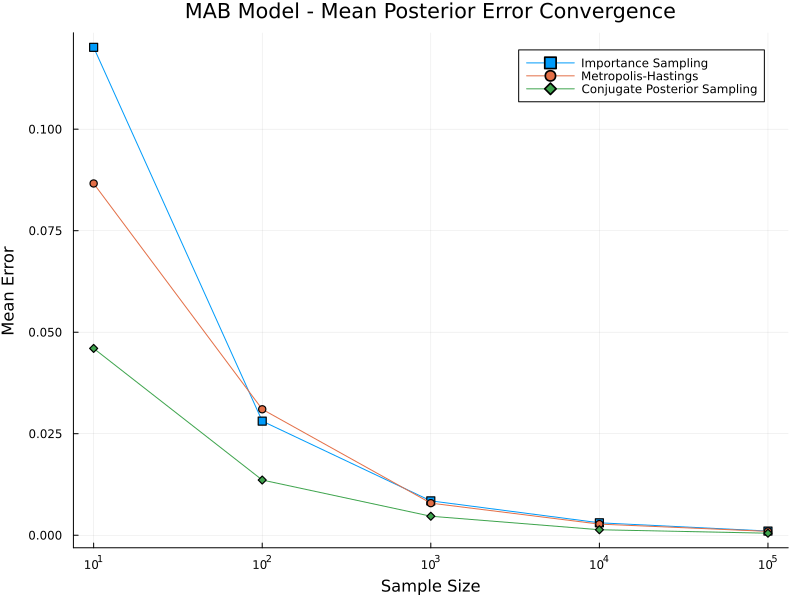

In [7]:
# Parameters passed through comparison function
sample_sizes = [10, 100, 1000, 10000, 100_000] # For experiments (sample sizes to be tested)
results = compare_convergence(
    sample_sizes,  # Sample sizes to test
    prior_success,
    prior_fail,
    n_pulls_per_arm,
    observations,
    num_runs = 50  # Number of runs for each sample size
)

# Print results
println("Convergence Comparison for MAB:")
for (n, errs) in sort(collect(results))
    println("""
    Sample Size: $n
      IS Error: $(round(errs.is_error, digits=5))
      Conjugate Error: $(round(errs.conjugate_error, digits=5))
      MH Error: $(round(errs.mh_error, digits=5))
    """)
end

# Error convergence plot
p = plot_convergence(results, sample_sizes)
display(p)

## Beta-Bernoulli model

In [8]:
# Model Definition for beta bernoulli
@gen function beta_bernoulli_model(alpha_prior, beta_prior, total_trials)
    # Sample theta from beta according to our prior
    theta = ({:theta} ~ beta(alpha_prior, beta_prior))
    
    # Bernoulli(theta), calculate what our win chances are from all trials and theta
    for i in 1:total_trials
        ({(:data, i)} ~ bernoulli(theta))
    end
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Any, Any, Any], false, Union{Nothing, Some{Any}}[nothing, nothing, nothing], Main.var"##beta_bernoulli_model#232", Bool[0, 0, 0], false)

### Gen built-in inference techniques

In [9]:
# importance sampling
function is_inference_beta_bernoulli(
    alpha_prior,
    beta_prior,
    total_trials,
    observations::Gen.ChoiceMap,
    num_samples
)
    (traces, log_weights, _) = Gen.importance_sampling(
        beta_bernoulli_model,
        (alpha_prior, beta_prior, total_trials),
        observations,
        num_samples
    )
    return traces, exp.(log_weights)
end

# Metropolis hastings
function mh_inference_beta_bernoulli(
    alpha_prior,
    beta_prior,
    total_trials,
    observations::Gen.ChoiceMap,
    num_iters;
    burn_in::Int=1000
)
    # Generate initial trace
    (trace, _) = Gen.generate(
        beta_bernoulli_model,
        (alpha_prior, beta_prior, total_trials),
        observations
    )
    
    traces = Vector{Gen.Trace}()
    
    # Run MH updates and collect traces after burn-in
    for iter in 1:(num_iters + burn_in)
        # Update theta parameter
        selection = Gen.select(:theta)  # Single parameter selection
        (trace, _) = Gen.metropolis_hastings(trace, selection)
        
        # Store trace after burn-in period
        if iter > burn_in
            push!(traces, trace)
        end
    end
    
    return traces
end

mh_inference_beta_bernoulli (generic function with 1 method)

### Custom Inference technique for Beta-Bernoulli model

In [10]:
# Custom inference using conjugate beta prior on bernoulli
function beta_bernoulli_conjugate_inference(
    alpha_prior,
    beta_prior,
    N,  # Total number of observations
    observations::Gen.ChoiceMap,
    num_samples
)
    # Calculate total successes from observations
    total_successes = sum([observations[(:data, i)] for i in 1:N])
    
    # Calculate posterior parameters
    post_alpha = alpha_prior + total_successes
    post_beta = beta_prior + (N - total_successes)
    
    # Generate samples as proper Gen traces
    traces = Vector{Gen.Trace}()
    model_args = (alpha_prior, beta_prior, N)
    
    for _ in 1:num_samples
        # Create choices with sampled theta and fixed observations
        choices = Gen.choicemap()
        choices[:theta] = rand(Beta(post_alpha, post_beta))
        
        # Merge with observations
        merged_choices = Gen.merge(choices, observations)
        
        # Generate valid Gen trace
        trace, _ = Gen.generate(
            beta_bernoulli_model,
            model_args,
            merged_choices
        )
        push!(traces, trace)
    end
    
    return traces
end

beta_bernoulli_conjugate_inference (generic function with 1 method)

### Comparison functions for beta-bernoulli inference

In [11]:
function compare_convergence_beta_bernoulli(
    sample_sizes,
    prior_alpha,
    prior_beta,
    total_trials,
    observations::Gen.ChoiceMap;
    num_runs::Int = 10
)
    # Calculate analytical truth
    total_successes = sum([observations[(:data, i)] for i in 1:total_trials])
    true_post_alpha = prior_alpha + total_successes
    true_post_beta = prior_beta + (total_trials - total_successes)
    true_mean = true_post_alpha / (true_post_alpha + true_post_beta)

    results = Dict{Int, NamedTuple}()

    for n in sample_sizes
        # Initialize error accumulators
        is_errors = zeros(num_runs)
        conjugate_errors = zeros(num_runs)
        mh_errors = zeros(num_runs)

        # Run multiple trials
        for run in 1:num_runs
            # Importance Sampling
            is_traces, is_weights = is_inference_beta_bernoulli(
                prior_alpha,
                prior_beta,
                total_trials,
                observations,
                n
            )
            is_mean = sum([tr[:theta] * w for (tr, w) in zip(is_traces, is_weights)])/sum(is_weights)
            is_errors[run] = abs(is_mean - true_mean)

            # Conjugate inference
            conjugate_traces = beta_bernoulli_conjugate_inference(
                prior_alpha,
                prior_beta,
                total_trials,
                observations,
                n
            )
            conjugate_mean = mean([tr[:theta] for tr in conjugate_traces])
            conjugate_errors[run] = abs(conjugate_mean - true_mean)

            # Metropolis-Hastings
            mh_traces = mh_inference_beta_bernoulli(
                prior_alpha,
                prior_beta,
                total_trials,
                observations,
                n
            )
            mh_mean = mean([tr[:theta] for tr in mh_traces])
            mh_errors[run] = abs(mh_mean - true_mean)
        end

        # Store average errors
        results[n] = (
            is_error = mean(is_errors),
            is_std = std(is_errors),
            conjugate_error = mean(conjugate_errors),
            conjugate_std = std(conjugate_errors),
            mh_error = mean(mh_errors),
            mh_std = std(mh_errors)
        )
    end

    return results
end

function plot_convergence_beta_bernoulli(results, sample_sizes)
    p = plot(xlabel="Sample Size", ylabel="Mean Error", 
             xscale=:log,
             xticks = sample_sizes,
             title="Beta-Bernoulli Model - Mean Posterior Error Convergence", 
             legend=:topright, size=(800, 600))

    # Convert sample sizes to Float64 for log scale plotting
    x_vals = sample_sizes

    # Importance Sampling
    is_errors = [results[n].is_error for n in sample_sizes]
    plot!(p, x_vals, is_errors, label="Importance Sampling", marker=:square)

    # Metropolis-Hastings
    mh_errors = [results[n].mh_error for n in sample_sizes]
    plot!(p, x_vals, mh_errors, label="Metropolis-Hastings", marker=:circle)

    # Conjugate
    conjugate_errors = [results[n].conjugate_error for n in sample_sizes]
    plot!(p, x_vals, conjugate_errors, label="Conjugate Posterior Sampling", marker=:diamond)

    return p
end

plot_convergence_beta_bernoulli (generic function with 1 method)

### Inference on beta-bernoulli model

In [12]:
# Initial parameters for experiments
prior_alpha = 1.0
prior_beta = 1.0
total_trials = 10

# Create and set observations
observations = choicemap()
data = [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]  # 7 successes, 3 failuress
for (i, outcome) in enumerate(data)
    observations[(:data, i)] = outcome
end

### Test runs

In [13]:
# Run conjugate inference
conjugate_traces = beta_bernoulli_conjugate_inference(
    prior_alpha,
    prior_beta,
    total_trials,
    observations,
    10000
)

# Run importance sampling
is_traces, is_weights = is_inference_beta_bernoulli(
    prior_alpha,
    prior_beta,
    total_trials,
    observations,
    10000
)

# Run MH inference
mh_traces = mh_inference_beta_bernoulli(
    prior_alpha,
    prior_beta,
    total_trials,
    observations,
    10000
)

# Calculate means
conjugate_mean = mean([tr[:theta] for tr in conjugate_traces])
mh_mean = mean([tr[:theta] for tr in mh_traces])
is_theta = [tr[:theta] for tr in is_traces]
is_mean = sum(is_weights .* is_theta) / sum(is_weights) 

# Analytical posterior mean
total_successes = sum(data)
analytical_mean = (prior_alpha + total_successes) / (prior_alpha + prior_beta + total_trials)

# Print results
println("Analytical Posterior Mean: ", round(analytical_mean, digits=4))
println("Conjugate Sampling Mean:   ", round(conjugate_mean, digits=4))
println("MH Sampling Mean:          ", round(mh_mean, digits=4))
println("IS Weighted Mean:          ", round(is_mean, digits=4))

Analytical Posterior Mean: 0.6667
Conjugate Sampling Mean:   0.6662
MH Sampling Mean:          0.6658
IS Weighted Mean:          0.6668


### Comparison of inference techniques on Beta-Bernoulli

Beta-Bernoulli Convergence Comparison:
Sample Size: 10
  IS Error: 0.042
  Conjugate Error: 0.03217
  MH Error: 0.07035

Sample Size: 100
  IS Error: 0.01155
  Conjugate Error: 0.01029
  MH Error: 0.01685

Sample Size: 1000
  IS Error: 0.00426
  Conjugate Error: 0.00305
  MH Error: 0.0068

Sample Size: 10000
  IS Error: 0.00143
  Conjugate Error: 0.00107
  MH Error: 0.00166

Sample Size: 100000
  IS Error: 0.00032
  Conjugate Error: 0.0003
  MH Error: 0.0005



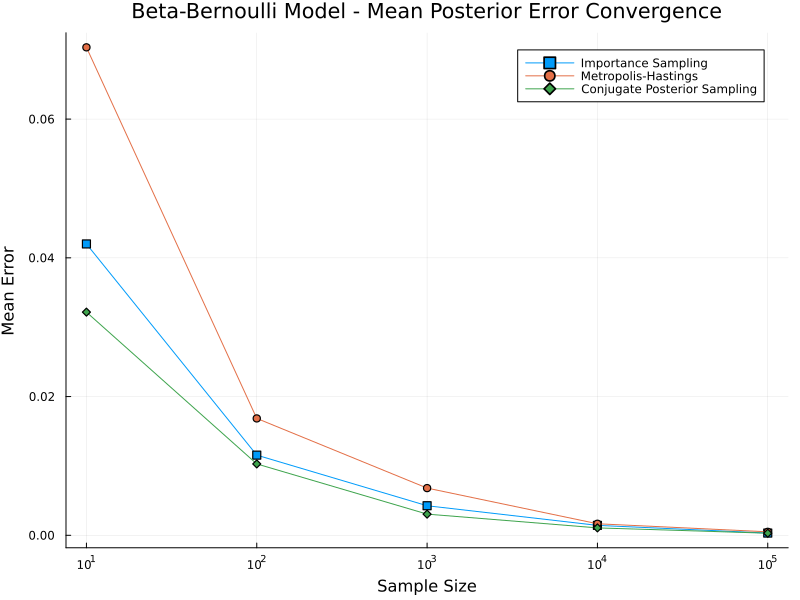

In [14]:
# Sample sizes for experiment
sample_sizes = [10, 100, 1000, 10000, 100_000]
# Run comparison
results = compare_convergence_beta_bernoulli(
    sample_sizes,
    prior_alpha,
    prior_beta,
    total_trials,
    observations,
    num_runs=50
)

# Print results
println("Beta-Bernoulli Convergence Comparison:")
for (n, errs) in sort(collect(results))
    println("""
    Sample Size: $n
      IS Error: $(round(errs.is_error, digits=5))
      Conjugate Error: $(round(errs.conjugate_error, digits=5))
      MH Error: $(round(errs.mh_error, digits=5))
    """)
end

# Plot results
p = plot_convergence_beta_bernoulli(results, sample_sizes)
display(p)

### Combined inference posterior technique

In [15]:
function combined_conjugate_inference(
    prior_success::Union{Vector{Float64}, Float64},
    prior_fail::Union{Vector{Float64}, Float64},
    n_pulls::Union{Vector{Int}, Int},
    observations::Gen.ChoiceMap,
    num_samples::Int
)
    # Determine model type based on input types
    is_mab = prior_success isa Vector
    
    if is_mab
        # MAB Model Parameters
        n_arms = length(prior_success)
        successes = [observations[(:obs, i)] for i in 1:n_arms]
        model = multi_armed_bandit_model
        model_args = (prior_success, prior_fail, n_pulls)
    else
        # Beta-Bernoulli Model Parameters
        N = n_pulls
        successes = sum([observations[(:data, i)] for i in 1:N])
        model = beta_bernoulli_model
        model_args = (prior_success, prior_fail, N)
    end
    
    # Calculate posterior parameters
    post_alpha = is_mab ? prior_success .+ successes : prior_success + successes
    post_beta = is_mab ? prior_fail .+ n_pulls .- successes : prior_fail + (n_pulls - successes)
    
    # Generate samples as proper Gen traces
    traces = Vector{Gen.Trace}()
    
    for _ in 1:num_samples
        choices = Gen.choicemap()
        
        if is_mab
            # MAB: Create choices for each arm
            for i in 1:n_arms
                choices[(:theta, i)] = rand(Beta(post_alpha[i], post_beta[i]))
            end
        else
            # just beta-bernoulli: Create single theta choice
            choices[:theta] = rand(Beta(post_alpha, post_beta))
        end
        
        # Merge with observations and generate trace
        merged_choices = Gen.merge(choices, observations)
        trace, _ = Gen.generate(model, model_args, merged_choices)
        push!(traces, trace)
    end
    
    return traces
end

combined_conjugate_inference (generic function with 1 method)